In [ ]:
import os
import kagglehub
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

path = kagglehub.dataset_download("preetviradiya/brian-tumor-dataset")
print("Path ke file dataset:", path)

image_paths = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
            image_paths.append(os.path.join(root, file))

print(f"Total gambar ditemukan: {len(image_paths)}")

Converged in 16 iteration


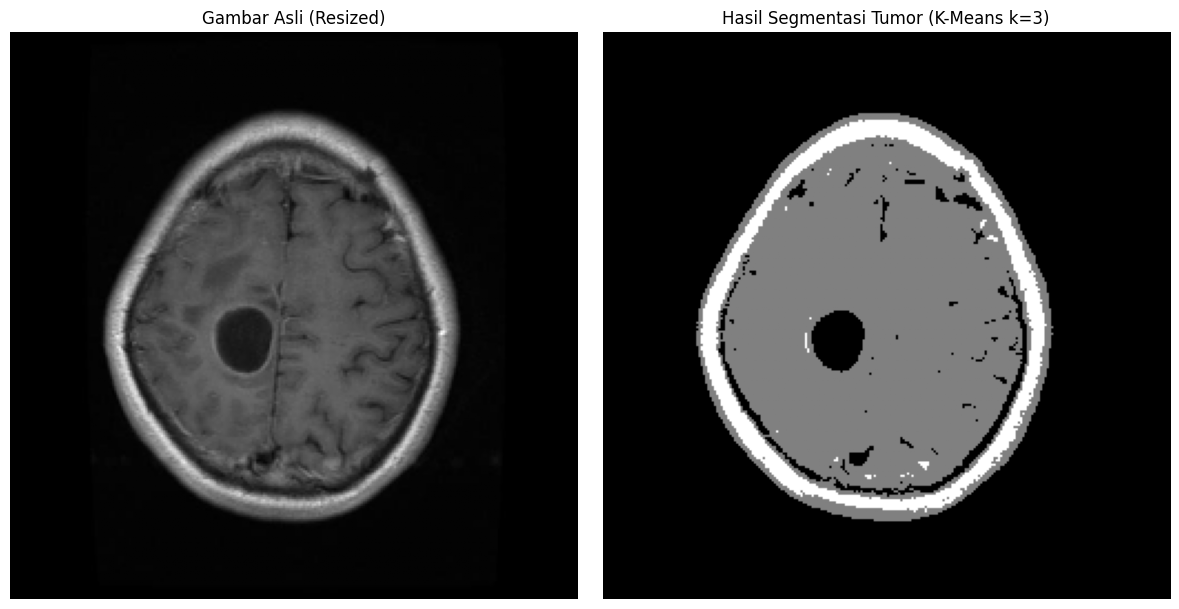

In [ ]:
def preprocess_image(image_path, target_size=(256, 256)):
    img = cv2.imread(image_path)
    img_converted = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img_converted, target_size)
    flat_img = img_resized.reshape(-1, 1)

    flat_img = np.float32(flat_img)

    return flat_img, img_resized


def initialize_centroids(X, k):
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]
def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

'''
scratch version of assign_cluster
def euclidean_distance(c1, c2):
    total = 0.0
    for i in range(len(c1)):
        diff = c1[i] - c2[i]
        total += diff * diff
    return total ** 0.5

def distance(centroids1, centroids2):
    total_distance = 0.0
    for c1 in centroids1:
        min_dist = float('inf')
        for c2 in centroids2:
            dist = euclidean_distance(c1, c2)
            if dist < min_dist:
                min_dist = dist
        total_distance += min_dist
    return total_distance
def assign_clusters(X, centroids):
    cluster_labels = []

    for x in X:
        distances = []

        for centroid in centroids:
            dist = distance_kmeans([x], [centroid])
            distances.append(dist)

        cluster_labels.append(np.argmin(distances))

    return np.array(cluster_labels)
'''

def update_centroids(X, cluster_labels, k):
    new_centroids = np.zeros((k, X.shape[1]))
    for i in range(k):
        points = X[cluster_labels== i]
        if len(points) > 0:
            new_centroids[i] = np.mean(points, axis=0)
        else:
            new_centroids[i] = X[np.random.choice(X.shape[0])]
    return new_centroids

def kmeans_from_scratch(X, k, max_iters=100, tol=1e-4):
    centroids = initialize_centroids(X, k)
    for i in range(max_iters):
        cluster_labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, cluster_labels, k)

        if np.all(np.abs(new_centroids - centroids) < tol):
            print(f"Converged in {i+1} iteration")
            break
        centroids = new_centroids

    return centroids, cluster_labels

if len(image_paths) > 0:
    sample_path = image_paths[0]
    pixels,img_resized = preprocess_image(sample_path)

    k = 3
    centroids, labels = kmeans_from_scratch(pixels, k)

    segmented_pixels = centroids[labels]
    segmented_img = segmented_pixels.reshape(img_resized.shape).astype(np.uint8)
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_resized, cmap='gray')
    plt.title("Gambar Asli (Resized)")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(segmented_img, cmap='gray')
    plt.title(f"Hasil Segmentasi Tumor (K-Means k={k})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print("Error: Tidak ada file gambar yang ditemukan di dalam folder dataset.")

In [2]:
def distance_knn(centroids1, centroids2):
    distances = np.linalg.norm(centroids1[:, np.newaxis] - centroids2,axis=2)
    min_distances = np.min(distances, axis=1)
    return np.sum(min_distances)

def modified_knn(test_image_centroids, training_features, training_labels, k_neighbors=5):
    distances_with_labels = []
    epsilon = 1e-6
    for i, train_centroids in enumerate(training_features):
        dist = distance_knn(test_image_centroids, train_centroids)
        distances_with_labels.append((dist, training_labels[i]))

    distances_with_labels.sort(key=lambda x: x[0])
    nearest_neighbors = distances_with_labels[:k_neighbors]

    vote_scores = {0: 0.0, 1: 0.0}
    for dist, label in nearest_neighbors:
        weight = 1.0 / (dist + epsilon)
        vote_scores[label] += weight

    if vote_scores[1] > vote_scores[0]:
        return 1
    elif vote_scores[0] > vote_scores[1]:
        return 0
    else:
        return random.choice([0, 1])

def predict_new_image(image_path, training_features, training_labels, k_kmeans=3, k_knn=3):
    try:
        flat_img, img_for_display = preprocess_image(image_path)

        test_centroids, _ = kmeans_from_scratch(flat_img, k=k_kmeans, max_iters=50, tol=1e-3)

        predicted_label = modified_knn(
            test_centroids,
            training_features,
            training_labels,
            k_neighbors=k_knn
        )

        return predicted_label, img_for_display

    except Exception as e:
        print(f"Gagal memproses gambar: {e}")
        return None, None

#This one take so longggggg

In [ ]:
'''
import glob

image_files = (
    glob.glob(os.path.join(path, '**', '*.jpg'), recursive=True) +
    glob.glob(os.path.join(path, '**', '*.png'), recursive=True)
)

tumor_image_files = [f for f in image_files if os.path.basename(os.path.dirname(f)) == 'Brain Tumor']
healthy_image_files = [f for f in image_files if os.path.basename(os.path.dirname(f)) == 'Healthy']

k_scratch = 3
n_train_per_class = 5
random.seed(42)

train_tumor_paths = random.sample(tumor_image_files, n_train_per_class)
train_healthy_paths = random.sample(healthy_image_files, n_train_per_class)
training_paths = [(p, 1) for p in train_tumor_paths] + [(p, 0) for p in train_healthy_paths]
random.shuffle(training_paths)

training_features_centroids = []
training_labels = []

print("Mengekstrak centroid untuk data training...")
for img_path, label in training_paths:
    try:
        flat_img, _ = preprocess_image(img_path)

        _, image_centroids = kmeans_from_scratch(flat_img, k_scratch, max_iters=50, tol=1e-3)
        training_features_centroids.append(image_centroids)
        training_labels.append(label)
    except Exception as e:
        print(f"Error memproses {img_path}: {e}")
        continue

all_training_paths_set = {p for p, _ in training_paths}
available_test_tumor_paths = [p for p in tumor_image_files if p not in all_training_paths_set]
available_test_healthy_paths = [p for p in healthy_image_files if p not in all_training_paths_set]

if available_test_tumor_paths and available_test_healthy_paths:
    test_image_path = random.choice(available_test_tumor_paths)
    true_label = 1
    print(f"\nSelected test image: {os.path.basename(test_image_path)} (True Label: Tumor)")
else:
    print("\nNot enough unique images. Using one from training set.")
    test_image_path, true_label = training_paths[0]

test_flat_image_array, test_image_array = preprocess_image(test_image_path)

_, test_centroids = kmeans_from_scratch(test_flat_image_array, k_scratch, max_iters=50, tol=1e-3)

predicted_label = modified_knn_classify(test_centroids, training_features_centroids, training_labels, k_neighbors=5)

plt.figure(figsize=(6, 6))
plt.imshow(test_image_array) # test_image_array ini hasil resize dari fungsi preprocess
plt.title(f'Test Image: {os.path.basename(test_image_path)}\nPredicted: {"Tumor" if predicted_label==1 else "Healthy"} (True: {"Tumor" if true_label==1 else "Healthy"})')
plt.axis('off')
plt.show()

print(f"\nPrediction for {os.path.basename(test_image_path)}:")
print(f"   True Label: {'Tumor' if true_label==1 else 'Healthy'}")
print(f"   Predicted Label: {'Tumor' if predicted_label==1 else 'Healthy'}")
'''

'\nimport glob\n\nimage_files = (\n    glob.glob(os.path.join(path, \'**\', \'*.jpg\'), recursive=True) +\n    glob.glob(os.path.join(path, \'**\', \'*.png\'), recursive=True)\n)\n\ntumor_image_files = [f for f in image_files if os.path.basename(os.path.dirname(f)) == \'Brain Tumor\']\nhealthy_image_files = [f for f in image_files if os.path.basename(os.path.dirname(f)) == \'Healthy\']\n\nk_scratch = 3\nn_train_per_class = 5\nrandom.seed(42)\n\ntrain_tumor_paths = random.sample(tumor_image_files, n_train_per_class)\ntrain_healthy_paths = random.sample(healthy_image_files, n_train_per_class)\ntraining_paths = [(p, 1) for p in train_tumor_paths] + [(p, 0) for p in train_healthy_paths]\nrandom.shuffle(training_paths)\n\ntraining_features_centroids = []\ntraining_labels = []\n\nprint("Mengekstrak centroid untuk data training...")\nfor img_path, label in training_paths:\n    try:\n        flat_img, _ = preprocess_image(img_path)\n\n        _, image_centroids = kmeans_from_scratch(flat_img, 

# Parallelization make it faster

In [ ]:
import cv2
import numpy as np
import random
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import glob

def extract_centroid_worker(img_path, label, k_scratch):
    try:
        current_flat_image_array, _ = preprocess_image(img_path)

        image_centroids, _ = kmeans_from_scratch(current_flat_image_array, k_scratch, max_iters=50, tol=1e-3)
        return image_centroids, label
    except Exception as e:
        return None
image_files = glob.glob(os.path.join(path, '**', '*.jpg'), recursive=True) + glob.glob(os.path.join(path, '**', '*.png'), recursive=True)

tumor_image_files = [f for f in image_files if os.path.basename(os.path.dirname(f)) == 'Brain Tumor']
healthy_image_files = [f for f in image_files if os.path.basename(os.path.dirname(f)) == 'Healthy']

k_scratch = 3
n_train_per_class = 5
random.seed(42)

all_image_data = []
for p in tumor_image_files:
    all_image_data.append((p, 1))
for p in healthy_image_files:
    all_image_data.append((p, 0))

paths = [item[0] for item in all_image_data]
labels = [item[1] for item in all_image_data]

paths_train, paths_test, labels_train, labels_test = train_test_split(
    paths, labels, test_size=0.1, random_state=42, stratify=labels
)

print(f"Total images: {len(paths)}")
print(f"Training images: {len(paths_train)}")
print(f"Testing images: {len(paths_test)}")
print(f"Training Tumor ratio: {sum(labels_train)/len(labels_train):.2f}")
print(f"Testing Tumor ratio: {sum(labels_test)/len(labels_test):.2f}")

Total images: 4434
Training images: 3990
Testing images: 444
Training Tumor ratio: 0.53
Testing Tumor ratio: 0.53


In [ ]:
import time

start = time.time()

extract_centroid_worker(
    paths_train[0],
    labels_train[0],
    k_scratch
)

print("Detik:", time.time() - start)

In [ ]:
print("\nMengekstrak centroid untuk data training secara PARALEL...")
results_train = Parallel(n_jobs=-1)(
    delayed(extract_centroid_worker)(img_path, label, k_scratch)
    for img_path, label in tqdm(zip(paths_train, labels_train), total=len(paths_train), desc="Train Centroids")
)

X_train_centroids = []
labels_train_clean = []
for res in results_train:
    if res is not None:
        X_train_centroids.append(res[0])
        labels_train_clean.append(res[1])
labels_train = labels_train_clean

print(f"Berhasil mengekstrak centroid untuk {len(X_train_centroids)} gambar training.")

print("\nMengekstrak centroid untuk data testing secara PARALEL...")

results_test = Parallel(n_jobs=-1)(
    delayed(extract_centroid_worker)(img_path, label, k_scratch)
    for img_path, label in tqdm(zip(paths_test, labels_test), total=len(paths_test), desc="Test Centroids")
)

X_test_centroids = []
labels_test_clean = []
for res in results_test:
    if res is not None:
        X_test_centroids.append(res[0])
        labels_test_clean.append(res[1])
labels_test = labels_test_clean

print(f"Berhasil mengekstrak centroid untuk {len(X_test_centroids)} gambar testing.")



Mengekstrak centroid untuk data training secara PARALEL...


Train Centroids:   0%|          | 0/3990 [00:00<?, ?it/s]

Berhasil mengekstrak centroid untuk 3990 gambar training.

Mengekstrak centroid untuk data testing secara PARALEL...


Test Centroids:   0%|          | 0/444 [00:00<?, ?it/s]

Berhasil mengekstrak centroid untuk 444 gambar testing.


In [ ]:
import time

start = time.time()
y_pred = []
print("\nMelakukan klasifikasi pada data test...")

def knn_worker(test_centroids):
    return modified_knn(
        test_centroids,
        X_train_centroids,
        labels_train,
        k_neighbors=3
    )

y_pred = Parallel(n_jobs=-1)(
    delayed(knn_worker)(test_centroids)
    for test_centroids in tqdm(
        X_test_centroids,
        desc="Parallel Modified KNN Classification"
    )
)

end = time.time()

print("\nEvaluation Metrics")
print(f"Accuracy: {accuracy_score(labels_test, y_pred):.4f}")
print(f"Precision: {precision_score(labels_test, y_pred):.4f}")
print(f"Recall: {recall_score(labels_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(labels_test, y_pred):.4f}")
print("Confusion Matrix:\n", confusion_matrix(labels_test, y_pred))


Melakukan klasifikasi pada data test...


Parallel Modified KNN Classification:   0%|          | 0/444 [00:00<?, ?it/s]


Evaluation Metrics
Accuracy: 0.9414
Precision: 0.9646
Recall: 0.9237
F1 Score: 0.9437
Confusion Matrix:
 [[200   8]
 [ 18 218]]


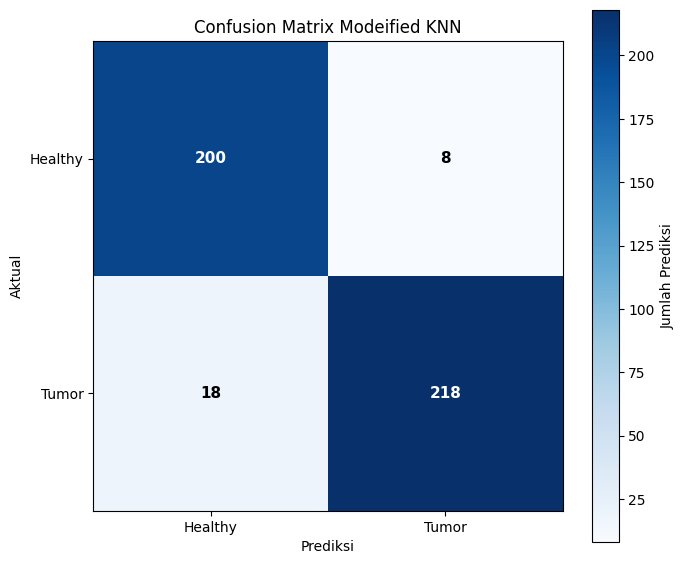

In [ ]:
cm = confusion_matrix(labels_test, y_pred)

labels = np.array([
    [cm[0][0], cm[0][1]],
    [cm[1][0], cm[1][1]]
    ])
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap='Blues')

cbar = plt.colorbar(im)
cbar.set_label('Jumlah Prediksi')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(['Healthy', 'Tumor'])
ax.set_yticklabels(['Healthy', 'Tumor'])

ax.set_xlabel('Prediksi')
ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix Modeified KNN')

threshold = cm.max() * 0.5

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i,
            labels[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > threshold else 'black',
            fontsize=11,
            fontweight='bold'
        )

plt.tight_layout()

plt.savefig(
    'confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
X_train_lib=[]
X_test_lib = []
for centroids in X_train_centroids:
  c = []
  c.append(centroids[0][0])
  c.append(centroids[1][0])
  c.append(centroids[2][0])
  X_train_lib.append(c)
for centroids in X_test_centroids:
  c = []
  c.append(centroids[0][0])
  c.append(centroids[1][0])
  c.append(centroids[2][0])
  X_test_lib.append(c)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)



print("Training KNN dengan Library...")

start = time.time()

knn = KNeighborsClassifier(
    n_neighbors=3,
    n_jobs=-1
)
knn.fit(X_train_lib, labels_train)

print("\nMelakukan klasifikasi secara PARALEL dengan KNN Library...")

def predict(test_centroids):
    prediction = knn.predict([test_centroids])[0]
    return prediction

pred = Parallel(n_jobs=-1)(
    delayed(predict)(test_centroids)
    for test_centroids in tqdm(
        X_test_lib,
        desc="Parallel KNN Library Classification"
    )
)

end = time.time()

print("\nEvaluation Metrics")
print(f"Accuracy : {accuracy_score(labels_test, pred):.4f}")
print(f"Precision: {precision_score(labels_test, pred):.4f}")
print(f"Recall   : {recall_score(labels_test, pred):.4f}")
print(f"F1 Score : {f1_score(labels_test, pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(labels_test, pred))

print(f"\nExecution Time: {end-start:.4f} seconds")

Training KNN dengan Library...

Melakukan klasifikasi secara PARALEL dengan KNN Library...


Parallel KNN Library Classification:   0%|          | 0/444 [00:00<?, ?it/s]


Evaluation Metrics
Accuracy : 0.7140
Precision: 0.7444
Recall   : 0.7034
F1 Score : 0.7233

Confusion Matrix:
[[151  57]
 [ 70 166]]

Execution Time: 5.4173 seconds


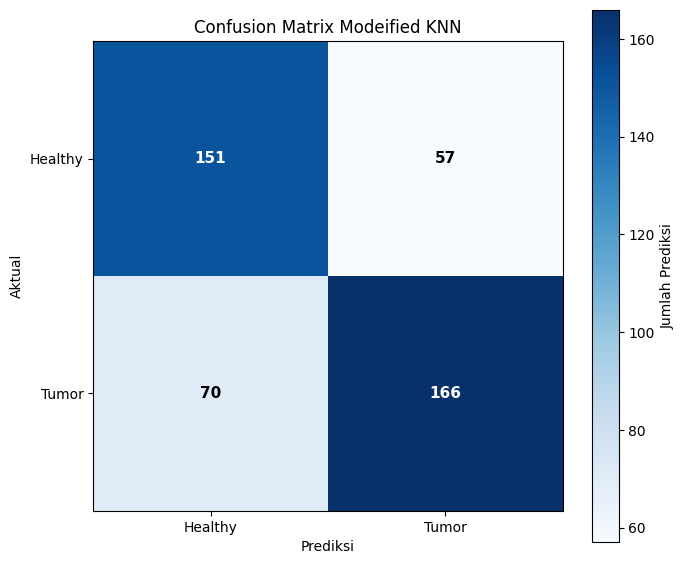

In [ ]:
cm = confusion_matrix(labels_test, pred)

labels = np.array([
    [cm[0][0], cm[0][1]],
    [cm[1][0], cm[1][1]]
    ])
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap='Blues')

cbar = plt.colorbar(im)
cbar.set_label('Jumlah Prediksi')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(['Healthy', 'Tumor'])
ax.set_yticklabels(['Healthy', 'Tumor'])

ax.set_xlabel('Prediksi')
ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix Modeified KNN')

threshold = cm.max() * 0.5

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i,
            labels[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > threshold else 'black',
            fontsize=11,
            fontweight='bold'
        )

plt.tight_layout()

plt.savefig(
    'confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
import kagglehub

# Download latest version
test_path = kagglehub.dataset_download("murtozalikhon/brain-tumor-multimodal-image-ct-and-mri")

print("Path to dataset files:", test_path)

100%|██████████| 361M/361M [00:08<00:00, 46.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/versions/1


In [ ]:
base_new_path = test_path + "/Dataset/Brain Tumor MRI images"
print(base_new_path)

/root/.cache/kagglehub/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/versions/1/Dataset/Brain Tumor MRI images


In [ ]:
import os
import glob
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import random

base_new_path = test_path + "/Dataset/Brain Tumor MRI images"
tumor_dir = os.path.join(base_new_path, "Tumor")
healthy_dir = os.path.join(base_new_path, "Healthy")

new_test_tumor_paths = glob.glob(os.path.join(tumor_dir, "*"))
new_test_healthy_paths = glob.glob(os.path.join(healthy_dir, "*"))

k_new  = 5

new_eval_data = (
    [(p, 1) for p in new_test_tumor_paths] +
    [(p, 0) for p in new_test_healthy_paths]
)

random.seed(42)
random.shuffle(new_eval_data)

image_paths = [p for p, label in new_eval_data]
labels = [label for p, label in new_eval_data]

print(f"Found {len(new_test_tumor_paths)} tumor images and {len(new_test_healthy_paths)} healthy images.")
print(f"Total images: {len(new_eval_data)}")

test_data = (
    [(p, 1) for p in new_test_tumor_paths] +
    [(p, 0) for p in new_test_healthy_paths]
)

random.seed(42)
random.shuffle(test_data)

paths_test = [p for p, _ in test_data]
labels_test = [label for _, label in test_data]

print("\nMengekstrak centroid untuk data baru secara PARALEL...")

results_test = Parallel(n_jobs=-1)(
    delayed(extract_centroid_worker)(img_path, label, k_scratch)
    for img_path, label in tqdm(zip(paths_test, labels_test), total=len(paths_test), desc="Test Centroids")
)

new_X_test_centroids = []
new_labels_test_clean = []
for res in results_test:
    if res is not None:
        new_X_test_centroids.append(res[0])
        new_labels_test_clean.append(res[1])
labels_test = new_labels_test_clean

print(f"Berhasil mengekstrak centroid untuk {len(new_X_test_centroids)} gambar testing.")

Found 3000 tumor images and 2000 healthy images.
Total images: 5000

Mengekstrak centroid untuk data baru secara PARALEL...


Test Centroids:   0%|          | 0/5000 [00:00<?, ?it/s]

Berhasil mengekstrak centroid untuk 5000 gambar testing.


In [ ]:
print("Processing new dataset and classifying in PARALLEL...")
results = Parallel(n_jobs=-1)(
    delayed(knn_worker)(test_centroids)
    for test_centroids in tqdm(
        new_X_test_centroids,
        desc="Parallel Modified KNN Classification New Data Test"
    )
)
print("No images were successfully processed for evaluation.")

Processing new dataset and classifying in PARALLEL...


Parallel Modified KNN Classification New Data Test:   0%|          | 0/5000 [00:00<?, ?it/s]

No images were successfully processed for evaluation.


In [ ]:
y_true_new = labels_test
y_pred_new = results


if y_true_new:
    print("\nEvaluation Metrics")
    print(f"Accuracy: {accuracy_score(y_true_new, y_pred_new):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true_new, y_pred_new))
    print("\nClassification Report:")
    print(classification_report(y_true_new, y_pred_new, target_names=['Healthy', 'Cancer']))



Evaluation Metrics
Accuracy: 0.8640
Confusion Matrix:
[[1719  281]
 [ 399 2601]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.81      0.86      0.83      2000
      Cancer       0.90      0.87      0.88      3000

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.87      0.86      0.86      5000



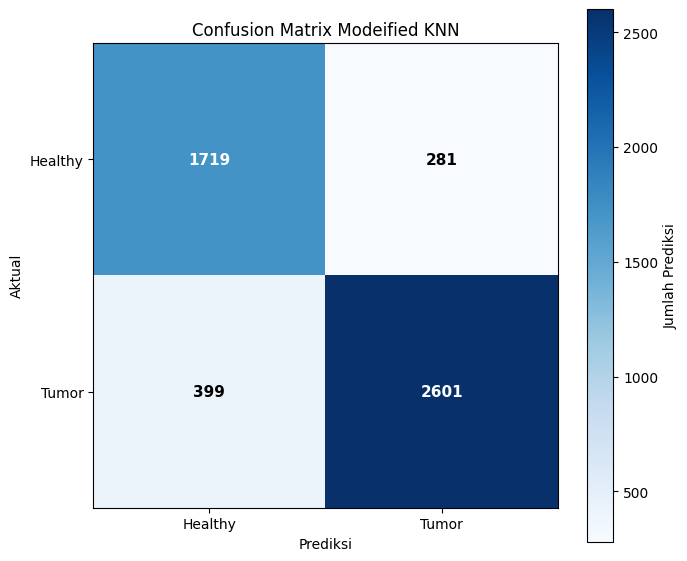

In [ ]:
cm = confusion_matrix(y_true_new, y_pred_new)

labels = np.array([
    [cm[0][0], cm[0][1]],
    [cm[1][0], cm[1][1]]
    ])
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap='Blues')

cbar = plt.colorbar(im)
cbar.set_label('Jumlah Prediksi')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(['Healthy', 'Tumor'])
ax.set_yticklabels(['Healthy', 'Tumor'])

ax.set_xlabel('Prediksi')
ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix Modeified KNN')

threshold = cm.max() * 0.5

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i,
            labels[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > threshold else 'black',
            fontsize=11,
            fontweight='bold'
        )

plt.tight_layout()

plt.savefig(
    'confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

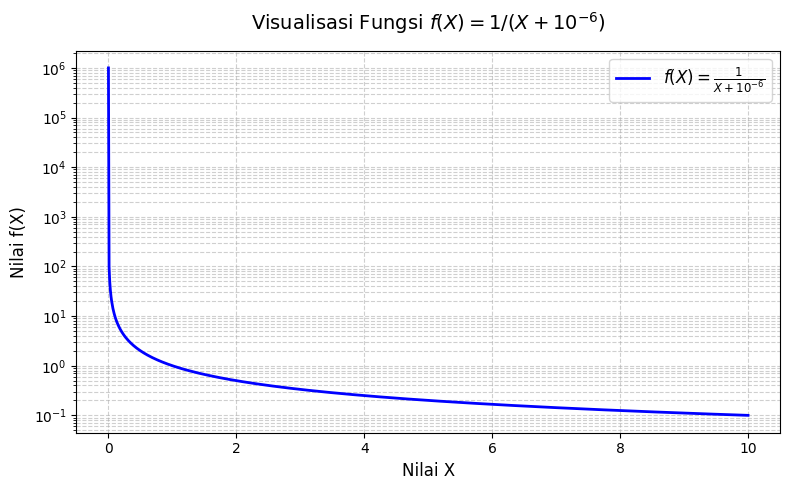

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 1000)

y = 1 / (x + 1e-6)


plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r'$f(X) = \frac{1}{X + 10^{-6}}$', color='blue', linewidth=2)

plt.yscale('log')

plt.title('Visualisasi Fungsi $f(X) = 1 / (X + 10^{-6})$', fontsize=14, pad=15)
plt.xlabel('Nilai X', fontsize=12)
plt.ylabel('Nilai f(X)', fontsize=12)

plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()